In [1]:
import numpy as np
import os
from ripser import ripser
from scipy.optimize import linear_sum_assignment
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

In [2]:
subject = 100206
state = 'tfMRI'
task = 'gambling'

In [3]:
data_dir = f"C:/Users/JINHWA/Projects/BrainNetworkTDA/Usedata/{state}_ts/{subject:06d}_{task}_dist/"

In [4]:
file_list = os.listdir(data_dir)
num_files = sum(
    1
    for filename in file_list
    if os.path.isfile(os.path.join(data_dir, filename))
)

print(f"There are {num_files} files in:\n  {data_dir}")

There are 55 files in:
  C:/Users/JINHWA/Projects/BrainNetworkTDA/Usedata/tfMRI_ts/100206_gambling_dist/


In [5]:
# === Parameters ===
n_frames = 55
start_frame, end_frame = 0, 55  # 원하는 구간으로 바꿔서 사용

# === Step 1: Load distance matrices ===
distance_matrices = []
for i in range(start_frame, end_frame):
    fname = os.path.join(data_dir, f"gambling100206_dist_matrix_{i:03d}.txt")
    mat = np.loadtxt(fname)
    distance_matrices.append(mat)

In [6]:
len(distance_matrices)

55

In [7]:
distance_matrices[0].shape

(116, 116)

In [8]:
# === Step 2: Compute persistence diagrams (H0 & H1) ===
diagrams_H0, diagrams_H1 = [], []
for mat in distance_matrices:
    result = ripser(mat, maxdim=1, distance_matrix=True)
    diagrams_H0.append(result['dgms'][0])
    diagrams_H1.append(result['dgms'][1])

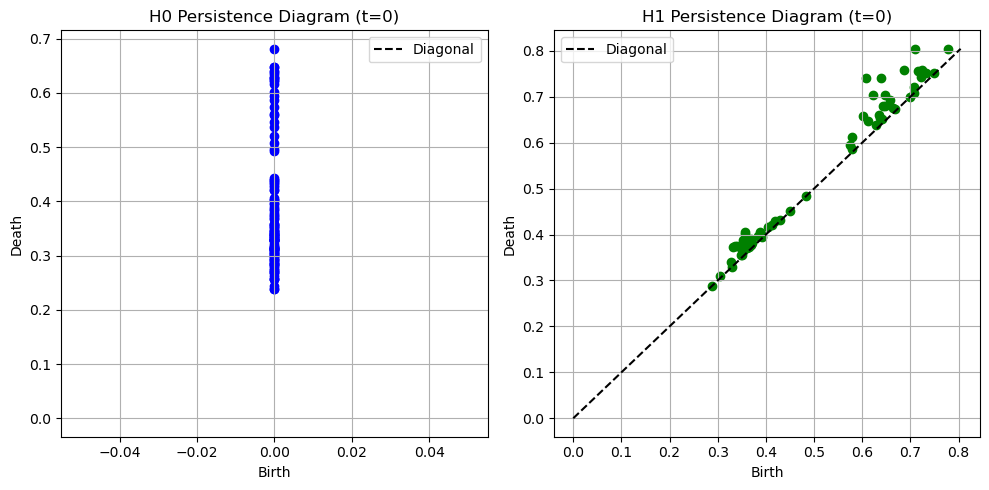

In [9]:
# === 시각화할 time step 지정 ===
sample_t = 0  # 0부터 시작

# === persistence diagram 가져오기 ===
dgm0 = diagrams_H0[sample_t]
dgm1 = diagrams_H1[sample_t]

# === 그림 그리기 ===
plt.figure(figsize=(10, 5))

# H0
plt.subplot(1, 2, 1)
plt.scatter(dgm0[:, 0], dgm0[:, 1], color='blue')
plt.plot([0, max(dgm0[:, 1])], [0, max(dgm0[:, 1])], 'k--', label='Diagonal')
plt.title(f'H0 Persistence Diagram (t={sample_t})')
plt.xlabel('Birth')
plt.ylabel('Death')
plt.grid(True)
plt.legend()

# H1
plt.subplot(1, 2, 2)
if len(dgm1) > 0:
    plt.scatter(dgm1[:, 0], dgm1[:, 1], color='green')
    plt.plot([0, max(dgm1[:, 1])], [0, max(dgm1[:, 1])], 'k--', label='Diagonal')
else:
    plt.text(0.5, 0.5, 'No H1 features', ha='center')
plt.title(f'H1 Persistence Diagram (t={sample_t})')
plt.xlabel('Birth')
plt.ylabel('Death')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()


In [10]:
diagrams_H1[0].shape

(63, 2)

In [11]:
diagrams_H1[0][np.all(np.isfinite(diagrams_H1[0]), axis=1)].shape

(63, 2)

In [12]:
# === Step 3: Build vines with Hungarian matching ===
def build_vines(diagrams, frame_count):
    max_points = max(len(dgm) for dgm in diagrams)
    vines = [[] for _ in range(max_points)]

    for t in range(frame_count - 1):
        D1 = diagrams[t]
        D2 = diagrams[t + 1]
        if len(D1) == 0 or len(D2) == 0:
            continue
        
        D1[np.isinf(D1)] = 1.0
        D2[np.isinf(D2)] = 1.0

        m, n = len(D1), len(D2)

        if m == 0 or n == 0:
            continue
        cost_matrix = np.full((max(m, n), max(m, n)), 1e9)
        cost_matrix[:m, :n] = np.max(np.abs(D1[:, None, :] - D2[None, :, :]), axis=2)
        row_ind, col_ind = linear_sum_assignment(cost_matrix)
        if t == 0:
            for i in range(len(row_ind)):
                if row_ind[i] < m and col_ind[i] < n:
                    vines[i].append((t, *D1[row_ind[i]]))
                    vines[i].append((t + 1, *D2[col_ind[i]]))
        else:
            for i in range(len(row_ind)):
                if row_ind[i] < m and col_ind[i] < n:
                    vines[i].append((t + 1, *D2[col_ind[i]]))
    return vines

vines_H0 = build_vines(diagrams_H0, len(distance_matrices))
vines_H1 = build_vines(diagrams_H1, len(distance_matrices))

In [13]:
print("There are", len(vines_H0), "vines in dimension 0 and", len(vines_H1), "vines in dimension 1.")

There are 116 vines in dimension 0 and 146 vines in dimension 1.


In [14]:
def vines_to_time_value(vines):
    """
    Given:
      vines: a list of vines, where each vine is a list of (t, birth, death) tuples.
    Returns:
      new_vines: a list of lists, where each sub-list is [(t, value), …],
                 and value = death - birth for each tuple.
    """
    new_vines = []
    for vine in vines:
        # If this vine is nonempty, convert each (t, b, d) → (t, d - b).
        if vine:
            tv_list = []
            for (t, birth, death) in vine:
                value = death - birth
                tv_list.append((t, value))
            new_vines.append(tv_list)
        else:
            # An empty vine stays empty
            new_vines.append([])
    return new_vines

# Example usage:
#   Suppose vines_H0 has shape [vine0, vine1, …], each vine_i = [(0,0,d0),(1,0,d1),…].
#   Then:
#     time_value_H0 = vines_to_time_value(vines_H0)
#   Each time_value_H0[i] will look like [(0, d0),(1, d1),…,(499, d499)].


# ——— If you also want to keep birth and death alongside value, use this version: ———
def vines_to_full_time_value(vines):
    """
    Given:
      vines: a list of vines, where each vine is a list of (t, birth, death) tuples.
    Returns:
      new_vines: a list of lists, where each sub-list is [(t, birth, death, value), …].
                 Here value = death - birth for each original tuple.
    """
    new_vines = []
    for vine in vines:
        if vine:
            full_list = []
            for (t, birth, death) in vine:
                value = death - birth
                full_list.append((t, birth, death, value))
            new_vines.append(full_list)
        else:
            new_vines.append([])
    return new_vines


In [15]:
# H0 / H1 Value List
scores_H0 = vines_to_time_value(vines_H0)
scores_H1 = vines_to_time_value(vines_H1)

In [16]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # required for 3D projection

def plot_vines_2d(vines, start_idx=0, end_idx=None):
    """
    Plot a 2D persistence vineyard for a specified range of vines.
    Each vine is given as a list of (time, value) tuples.
    Points are connected by line segments (no markers).

    Parameters:
    -----------
    vines : list of lists of tuples
        E.g., vines[i] = [(t0, v0), (t1, v1), …].

    start_idx : int, default=0
        First vine index to plot (inclusive).

    end_idx : int or None, default=None
        Last vine index to plot (inclusive). If None, plots to the end.
    """
    n_vines = len(vines)
    if end_idx is None or end_idx >= n_vines:
        end_idx = n_vines - 1

    plt.figure(figsize=(20, 5))
    cmap = plt.get_cmap('tab10')

    for idx in range(start_idx, end_idx + 1):
        vine = vines[idx]
        if not vine:
            continue  # skip empty vines

        times, values = zip(*vine)
        color = cmap((idx - start_idx) % 10)
        plt.plot(times, values, linestyle='-', color=color, label=f'vine_{idx}')

    plt.xlabel('Time Index')
    plt.ylabel('Value (death - birth)')
    plt.title(f'2D Persistence Vines (indices {start_idx} to {end_idx})')
    plt.grid(True)
    plt.legend(loc='upper right', fontsize='small', ncol=2)
    plt.tight_layout()
    plt.show()

In [17]:
import plotly.graph_objects as go

def plotly_vines_3d(vines, start_idx=0, end_idx=None):
    """
    Plotly를 사용해 3D Persistence Vine을 인터랙티브하게 시각화합니다.
    - x 축: time
    - y 축: birth
    - z 축: death

    Parameters
    ----------
    vines : list of lists of tuples
        각 vine[i] = [(t0, b0, d0), (t1, b1, d1), …] 형식.
    start_idx : int, default=0
        그리기 시작할 vine의 인덱스 (포함).
    end_idx : int or None, default=None
        그리기 끝낼 vine의 인덱스 (포함). None이면 리스트 끝까지.

    사용 예시:
        plotly_vines_3d(vines_H1, start_idx=5, end_idx=15)
    """
    n_vines = len(vines)
    if end_idx is None or end_idx >= n_vines:
        end_idx = n_vines - 1

    fig = go.Figure()

    # colormap: Plotly 기본 qualitative palette 중 하나 사용
    colors = [
        '#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd',
        '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf'
    ]

    for idx in range(start_idx, end_idx + 1):
        vine = vines[idx]
        if not vine:
            continue

        # 각 vine의 (t, b, d)를 별도 리스트로 분리
        times = [v[0] for v in vine]
        births = [v[1] for v in vine]
        deaths = [v[2] for v in vine]

        color = colors[(idx - start_idx) % len(colors)]
        name = f'vine_{idx}'

        # Plotly의 go.Scatter3d로 선분(line)만 그리기: mode='lines'
        fig.add_trace(go.Scatter3d(
            x=times,
            y=births,
            z=deaths,
            mode='lines',
            line=dict(color=color, width=4),  # 선 굵기는 4 정도가 보기 좋음
            name=name,
            hovertemplate=(
                'vine=' + name + '<br>' +
                'time=%{x:.0f}<br>' +
                'birth=%{y:.3f}<br>' +
                'death=%{z:.3f}<extra></extra>'
            )
        ))

    # 레이아웃 세팅
    fig.update_layout(
        title=f'Interactive 3D Persistence Vines (indices {start_idx} to {end_idx})',
        scene=dict(
            xaxis_title='Time',
            yaxis_title='Birth',
            zaxis_title='Death',
            # 축 범위를 0부터 max 값까지(원점에서 grid가 모이도록)
            xaxis=dict(nticks=10, range=[0, max([v[0] for vine in vines[start_idx:end_idx+1] for v in (vine if vine else [(0, 0, 0)])])]),
            yaxis=dict(nticks=10, range=[0, max([v[1] for vine in vines[start_idx:end_idx+1] for v in (vine if vine else [(0, 0, 0)])])]),
            zaxis=dict(nticks=10, range=[0, max([v[2] for vine in vines[start_idx:end_idx+1] for v in (vine if vine else [(0, 0, 0)])])]),
            camera=dict(
                eye=dict(x=1.5, y=-1.5, z=1.2)  # 초기 카메라(시점) 위치: x=앞→뒤, y=왼→오, z=밑→위
            )
        ),
        legend=dict(
            itemsizing='constant',
            x=0.8, y=0.9,
            bgcolor='rgba(255,255,255,0.5)',
            bordercolor='gray',
            borderwidth=1
        ),
        margin=dict(l=0, r=0, t=50, b=0)
    )

    fig.show()


In [18]:
print("There are", len(vines_H0), "vines in dimension 0 and", len(vines_H1), "vines in dimension 1.")

There are 116 vines in dimension 0 and 146 vines in dimension 1.


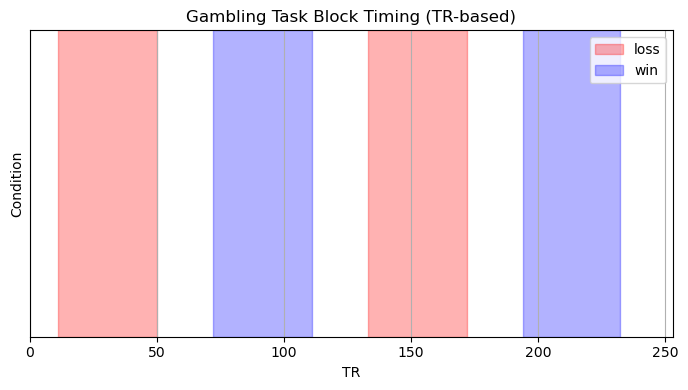

In [19]:
TR = 0.72
# Convert to TR-based onsets 
raw_blocks = [
    ("loss",  8.063, 28.0),
    ("win",  51.951, 28.0),
    ("loss", 95.840, 28.0),
    ("win", 139.742, 28.0),
]

corrected_blocks = []
for label, onset, duration in raw_blocks:

    start_tr = int(onset // TR)
    end_tr   = int((onset + duration) // TR)
    corrected_blocks.append((label, start_tr, end_tr))

# Plot
plt.figure(figsize=(7, 4))
for label, start_tr, end_tr in corrected_blocks:
    color = 'red' if label == 'loss' else 'blue'
    alpha = 0.3
    label_name = label if label not in plt.gca().get_legend_handles_labels()[1] else None
    plt.axvspan(start_tr, end_tr, color=color, alpha=alpha, label=label_name)

plt.xlabel("TR")
plt.ylabel("Condition")
plt.title("Gambling Task Block Timing (TR-based)")
plt.xlim(0, 253)  # full run duration
plt.yticks([])
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

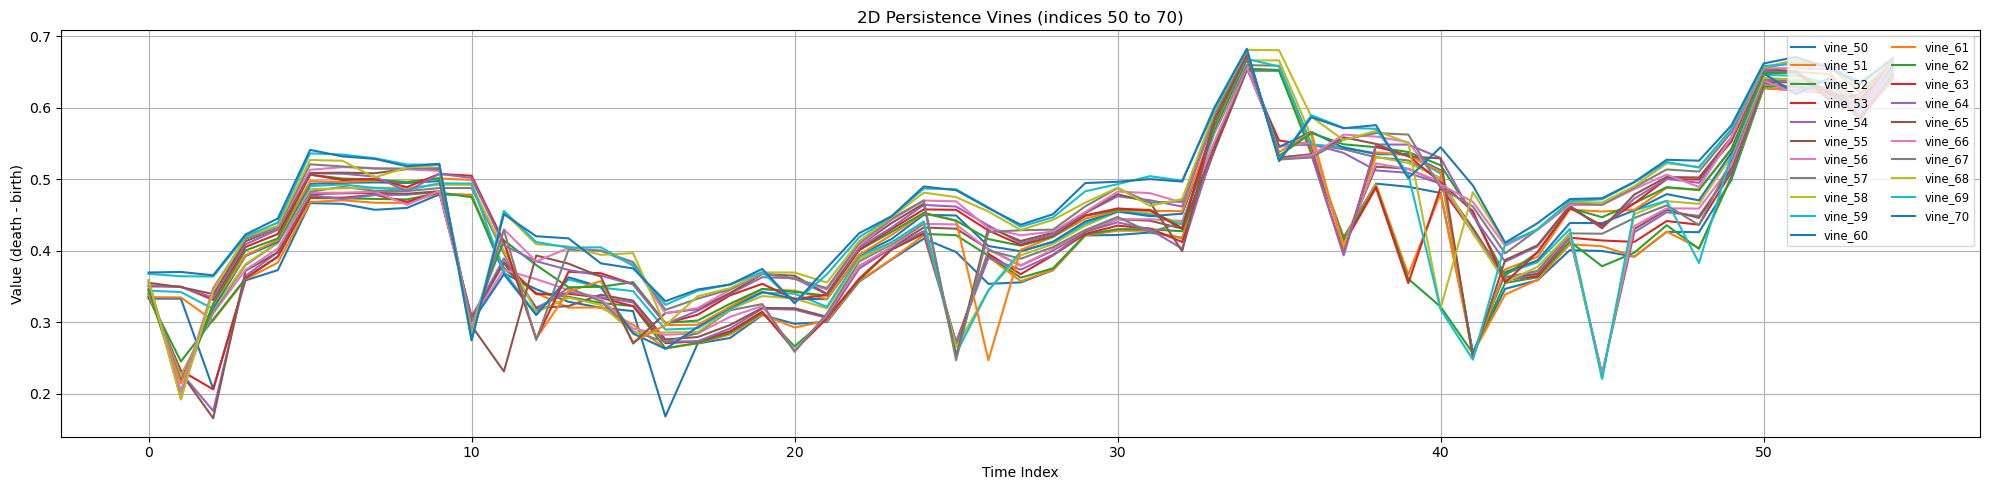

In [20]:
plot_vines_2d(scores_H0, start_idx=50, end_idx=70)


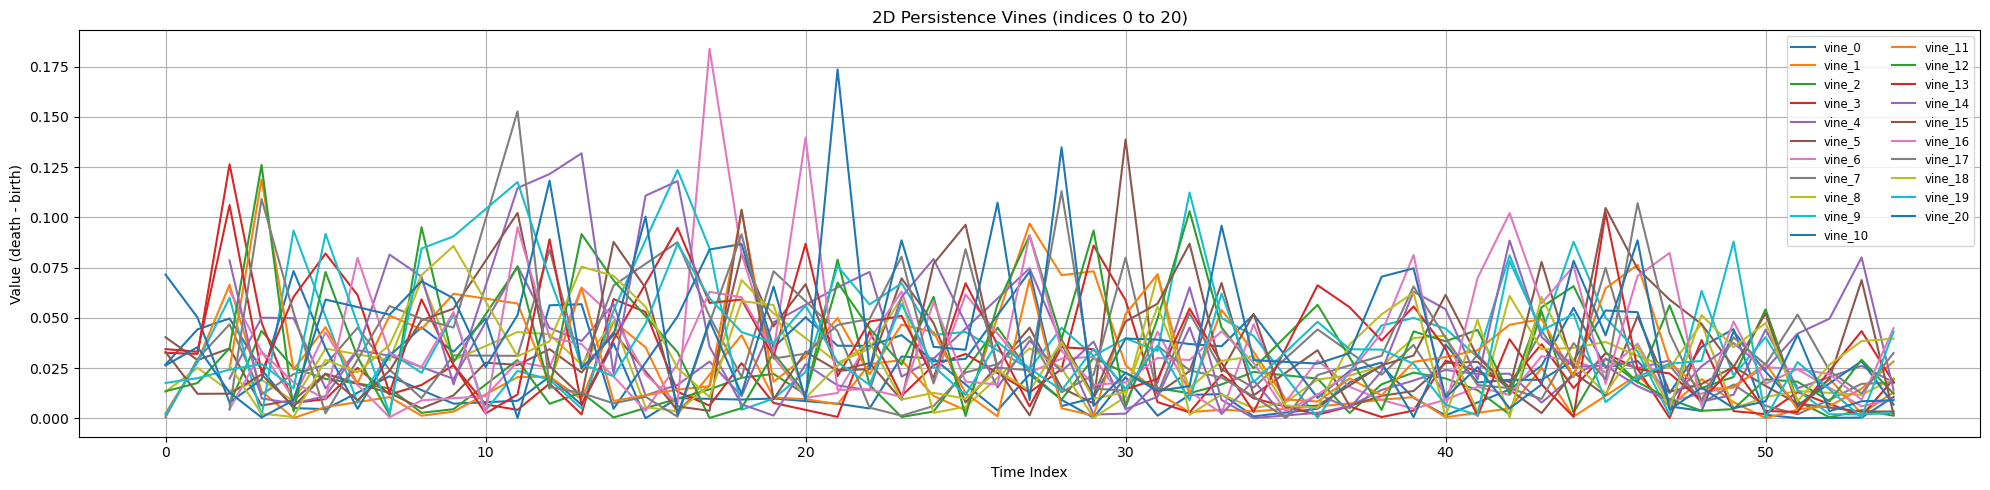

In [21]:
plot_vines_2d(scores_H1, start_idx=0, end_idx=20)

In [22]:
plotly_vines_3d(vines_H1, start_idx=5, end_idx=5)

In [23]:
plotly_vines_3d(vines_H1, start_idx=100, end_idx=100)

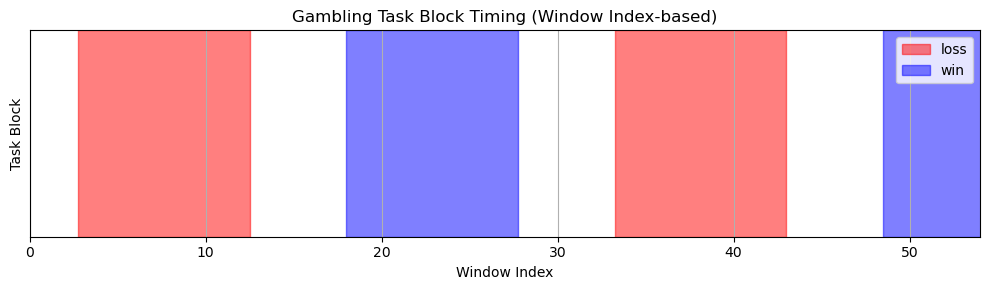


--- 원본 plot_vines_2d 함수 (블록 없음) 출력 ---


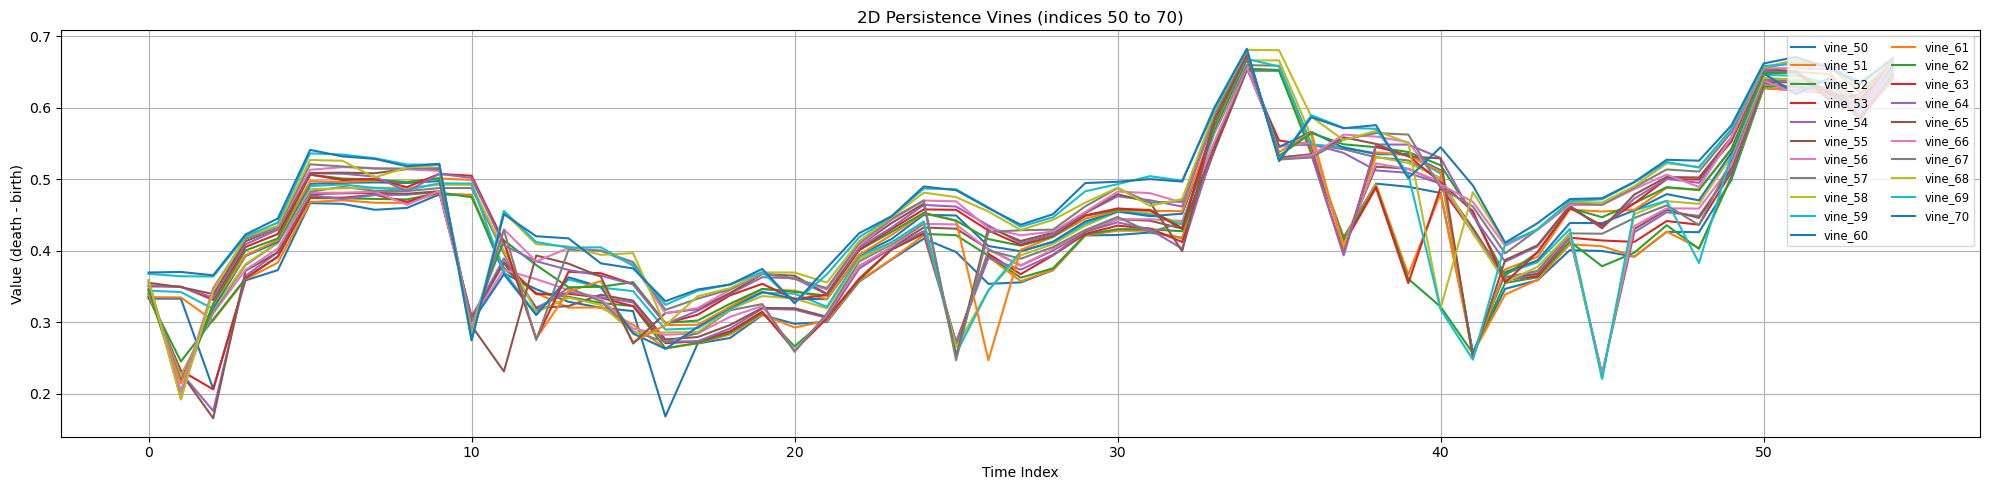


--- 블록이 오버레이된 2D Persistence Vines 출력 ---


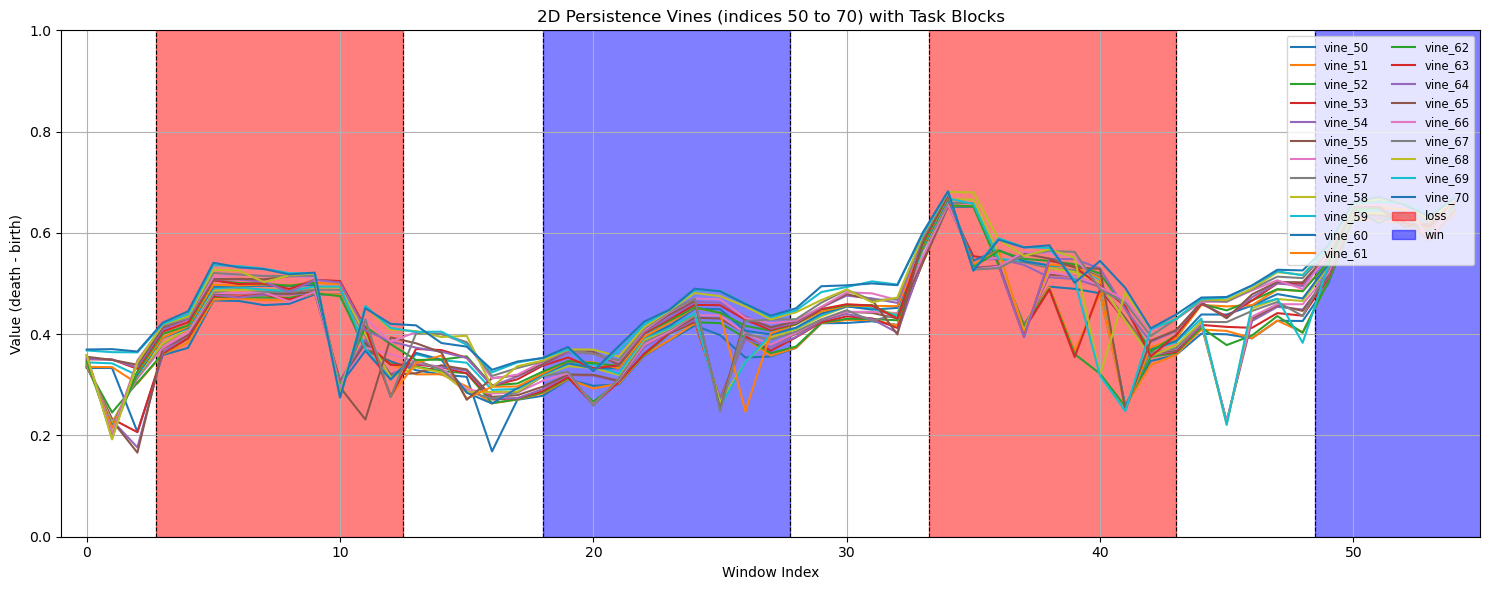

In [27]:
import matplotlib.pyplot as plt
import numpy as np

# --- User-provided ORIGINAL plot_vines_2d function (NO MODIFICATIONS) ---
def plot_vines_2d(vines, start_idx=0, end_idx=None):
    """
    Plot a 2D persistence vineyard for a specified range of vines.
    Each vine is given as a list of (time, value) tuples.
    Points are connected by line segments (no markers).

    Parameters:
    -----------
    vines : list of lists of tuples
        E.g., vines[i] = [(t0, v0), (t1, v1), …].

    start_idx : int, default=0
        First vine index to plot (inclusive).

    end_idx : int or None, default=None
        Last vine index to plot (inclusive). If None, plots to the end.
    """
    n_vines = len(vines)
    if end_idx is None or end_idx >= n_vines:
        end_idx = n_vines - 1

    plt.figure(figsize=(20, 5))
    cmap = plt.get_cmap('tab10')

    for idx in range(start_idx, end_idx + 1):
        vine = vines[idx]
        if not vine:
            continue  # skip empty vines

        times, values = zip(*vine)
        color = cmap((idx - start_idx) % 10)
        plt.plot(times, values, linestyle='-', color=color, label=f'vine_{idx}')

    plt.xlabel('Time Index')
    plt.ylabel('Value (death - birth)')
    plt.title(f'2D Persistence Vines (indices {start_idx} to {end_idx})')
    plt.grid(True)
    plt.legend(loc='upper right', fontsize='small', ncol=2)
    plt.tight_layout()
    plt.show() # This plt.show() prevents further modification of this specific plot

# --- User-provided data and parameters ---

TR = 0.72  # Repetition Time in seconds

# Raw block timings from EV files (onset in seconds, duration in seconds)
raw_blocks = [
    ("loss", 8.063, 28.0),
    ("win", 51.951, 28.0),
    ("loss", 95.840, 28.0),
    ("win", 139.742, 28.0),
]

# --- scores_H0 placeholder (REPLACE THIS WITH YOUR ACTUAL scores_H0 DATA) ---
# scores_H0는 (time, value) 튜플의 리스트를 포함하는 리스트여야 합니다.
# 예시: scores_H0 = [[(t0, v0), (t1, v1), ...], [(t0, v0), (t1, v1), ...], ...]
# plot_vines_2d 함수가 start_idx=50, end_idx=70을 사용하므로,
# 최소 71개의 'vine' (리스트)를 포함해야 합니다.
# 각 'vine'은 num_windows (55)개의 (time, value) 튜플을 포함해야 합니다.
num_windows = 55 # 슬라이딩 윈도우 수
min_vines_needed = 71 # plot_vines_2d의 end_idx=70을 커버하기 위해 필요한 최소 vine 수

/


# Sliding window parameters
window_size_tr = 35 # TRs
step_size_tr = 4    # TRs
original_time_length_tr = 253 # Total TRs of the run

# Calculate the start and end TR for each sliding window
window_start_trs = []
window_end_trs = []
current_start_tr = 0
while current_start_tr + window_size_tr <= original_time_length_tr:
    window_start_trs.append(current_start_tr)
    window_end_trs.append(current_start_tr + window_size_tr)
    current_start_tr += step_size_tr

# Ensure the number of windows matches your note (55 distance matrices)
assert len(window_start_trs) == 55, "Calculated number of windows does not match 55."

# Convert raw_blocks (onset in seconds) to TR-based onsets and durations for plotting
tr_based_blocks = []
for label, onset_sec, duration_sec in raw_blocks:
    start_tr = int(onset_sec / TR)
    end_tr = int((onset_sec + duration_sec) / TR)
    tr_based_blocks.append((label, start_tr, end_tr))

# --- Separate Plot for Block Timing on Window Index axis ---
def plot_block_timing_on_windows_only(tr_based_blocks, window_start_trs, step_size_tr, num_windows):
    """
    Plots task block timings on an x-axis representing Window Index.
    This helps visualize how original TR-based blocks align with sliding windows.
    This is a separate plot for clarity.
    """
    plt.figure(figsize=(10, 3))
    ax = plt.gca()
    
    block_legend_handles = []
    block_legend_labels = []

    for label, block_start_tr, block_end_tr in tr_based_blocks:
        # Map block TRs to window index scale
        block_start_mapped_idx = (block_start_tr - window_start_trs[0]) / step_size_tr
        block_end_mapped_idx = (block_end_tr - window_start_trs[0]) / step_size_tr

        color = 'red' if label == 'loss' else 'blue'
        alpha = 0.5 # More opaque for clarity in this separate plot
        
        # Use axvspan to draw the block
        ax.axvspan(block_start_mapped_idx, block_end_mapped_idx, color=color, alpha=alpha, zorder=0)

        if label not in block_legend_labels:
            block_legend_handles.append(plt.Rectangle((0, 0), 1, 1, color=color, alpha=alpha))
            block_legend_labels.append(label)

    ax.set_xlabel("Window Index")
    ax.set_ylabel("Task Block")
    ax.set_title("Gambling Task Block Timing (Window Index-based)")
    ax.set_xlim(0, num_windows - 1) # X-axis spans all window indices
    ax.set_yticks([]) # No y-ticks needed for this representation
    ax.grid(True)
    ax.legend(handles=block_legend_handles, labels=block_legend_labels, loc='upper right')
    plt.tight_layout()
    plt.show()

# --- NEW Plotting Logic: Recreate vines plot and overlap blocks ---
def plot_vines_and_overlap_blocks_recreated(vines, tr_based_blocks, window_start_trs, step_size_tr, num_windows,
                                            start_vine_idx=0, end_vine_idx=None):
    """
    Recreates the 2D persistence vines plot and overlays task blocks on it.
    This function duplicates the plotting logic of plot_vines_2d but adds block overlays.
    """
    n_vines = len(vines)
    if end_vine_idx is None or end_vine_idx >= n_vines:
        end_vine_idx = n_vines - 1

    fig, ax = plt.subplots(figsize=(15, 6)) # Create a new figure and axes

    cmap = plt.get_cmap('tab10')

    for idx in range(start_vine_idx, end_vine_idx + 1):
        vine = vines[idx]
        if not vine:
            continue  # skip empty vines

        times, values = zip(*vine)
        color = cmap((idx - start_vine_idx) % 10)
        ax.plot(times, values, linestyle='-', color=color, label=f'vine_{idx}')

    ax.set_xlabel('Window Index') # Consistent with sliding window interpretation
    ax.set_ylabel('Value (death - birth)')
    ax.set_title(f'2D Persistence Vines (indices {start_vine_idx} to {end_vine_idx}) with Task Blocks')
    ax.grid(True)

    # Determine the x-axis limits for the current vine plot to match the window indices
    if vines and vines[start_vine_idx:end_vine_idx+1]:
        all_times = [t for vine_data in vines[start_vine_idx:end_vine_idx+1] for t, _ in vine_data]
        if all_times:
            min_window_idx = min(all_times)
            max_window_idx = max(all_times)
            ax.set_xlim(min_window_idx - 1, max_window_idx + 1)
        else:
            ax.set_xlim(0, num_windows - 1)
    else:
        ax.set_xlim(0, num_windows - 1)

    # Set the y-axis limits as requested
    ax.set_ylim(0, 1)

    block_legend_handles = []
    block_legend_labels = []

    for label, block_start_tr, block_end_tr in tr_based_blocks:
        # Calculate the window index corresponding to the start of the block
        block_start_mapped_idx = (block_start_tr - window_start_trs[0]) / step_size_tr
        
        # Calculate the window index corresponding to the end of the block
        block_end_mapped_idx = (block_end_tr - window_start_trs[0]) / step_size_tr

        # Ensure the span has a positive width
        if block_end_mapped_idx <= block_start_mapped_idx:
            continue

        color = 'red' if label == 'loss' else 'blue'
        alpha = 0.5 # Increased alpha for better visibility
        
        # Add a vertical span for the block
        ax.axvspan(block_start_mapped_idx, block_end_mapped_idx, color=color, alpha=alpha, zorder=0)
        
        ax.axvline(block_start_mapped_idx, color='black', linestyle='--', linewidth=0.8, zorder=1)
        ax.axvline(block_end_mapped_idx, color='black', linestyle='--', linewidth=0.8, zorder=1)
            
        # Add a custom legend entry for the block, avoiding duplicates
        if label not in block_legend_labels:
            block_legend_handles.append(plt.Rectangle((0, 0), 1, 1, color=color, alpha=alpha))
            block_legend_labels.append(label)

    # Combine legends
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles + block_legend_handles, labels + block_legend_labels, 
              loc='upper right', fontsize='small', ncol=2)

    plt.tight_layout()
    plt.show()


# --- Execution ---

# 1. Plot the block timing on the Window Index axis separately (as requested previously)
plot_block_timing_on_windows_only(tr_based_blocks, window_start_trs, step_size_tr, num_windows)

# 2. Execute the user's ORIGINAL plot_vines_2d function (this will show a plot without blocks)
print("\n--- 원본 plot_vines_2d 함수 (블록 없음) 출력 ---")
plot_vines_2d(scores_H0, start_idx=50, end_idx=70)

# 3. Generate a NEW plot that recreates the vines and overlays the task blocks
print("\n--- 블록이 오버레이된 2D Persistence Vines 출력 ---")
plot_vines_and_overlap_blocks_recreated(scores_H0, tr_based_blocks, window_start_trs, step_size_tr, num_windows,
                                      start_vine_idx=50, end_vine_idx=70)

In [25]:
# plot_vines_and_overlap_blocks_recreated 함수 내에서
for label, block_start_tr, block_end_tr in tr_based_blocks:
    block_start_mapped_idx = (block_start_tr - window_start_trs[0]) / step_size_tr
    block_end_mapped_idx = (block_end_tr - window_start_trs[0]) / step_size_tr

    print(f"Block: {label}, TR Range: [{block_start_tr}, {block_end_tr}], "
          f"Window Index Range: [{block_start_mapped_idx:.2f}, {block_end_mapped_idx:.2f}]")
    # ... (나머지 코드)

Block: loss, TR Range: [11, 50], Window Index Range: [2.75, 12.50]
Block: win, TR Range: [72, 111], Window Index Range: [18.00, 27.75]
Block: loss, TR Range: [133, 172], Window Index Range: [33.25, 43.00]
Block: win, TR Range: [194, 232], Window Index Range: [48.50, 58.00]
